# 🌟 Algoritmo "Gemma Nascosta"
## Combinazione Indice Attrattività + Indice Overtourism

Questo notebook trasforma la logica di analisi in celle didattiche interattive.

### Il problema

Non basta conoscere l'attrattività di un territorio per consigliare una destinazione: un luogo bellissimo ma affollato offre un'esperienza diversa da un luogo altrettanto interessante ma ancora intatto. Dobbiamo **combinare** le due dimensioni — potenziale turistico e pressione antropica — per identificare le vere **gemme nascoste**.

### La formula

\[ gem\_score = indice\_attrattivita \times \left(1 - \frac{indice\_overtourism}{100}\right) \]

- Quando `indice_overtourism = 0` (nessuna pressione) → gem_score = attrattività piena
- Quando `indice_overtourism = 100` (massima pressione) → gem_score = 0
- Valori intermedi pesano proporzionalmente la riduzione

### Normalizzazione min-max

Il gem_score grezzo viene poi normalizzato in un range 0–100 per facilitarne la lettura:

\[ gem\_score\_normalized = \frac{gem\_score - min}{max - min} \times 100 \]

### Limiti interpretativi

- I pilastri di attrattività dipendono dalla **copertura OSM**; comuni con pochi POI avranno un punteggio basso anche se il territorio è interessante
- L'indice overtourism è una **proxy** (densità ricettiva, pressione parcheggi, …) e non misura direttamente la percezione del visitatore
- Le **mediane** come soglie sono robuste a outlier, ma dividono la popolazione in modo esatto al 50%: due comuni molto simili potrebbero finire in quadranti diversi
- Il **gem_score** è una metrica composita: due comuni con lo stesso valore potrebbero avere profili opposti

## 1 · Configurazione

Tutti i percorsi sono configurabili qui. Modificando `DATA_DIR` il notebook punta a un'altra directory senza toccare il resto del codice.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, json, sys

# ── Configurazione ──────────────────────────────────────────
DATA_DIR = "../"   # ← Cambia qui per un altro progetto

ATTRATTIVITA_CSV = os.path.join(DATA_DIR, "indicatore_attrattivita", "output_attrattivita", "indicatore_di_attrattivita.csv")
OVERTOURISM_CSV  = os.path.join(DATA_DIR, "indice_overtourism", "indice_overtourism_complessivo.csv")
OUTPUT_CSV       = os.path.join(DATA_DIR, "indicatore_gem_score/output_gem_score", "indicatore_gem_score.csv")

# ── Soglie quadranti ───────────────────────────────────────
# "auto"  → usa la mediana calcolata dai dati (consigliato)
# float   → usa quel valore fisso
SOGLIA_ATTRATTIVITA = "auto"   # es. 5.0 per una soglia personalizzata
SOGLIA_OVERTOURISM  = "auto"   # es. 30.0 per una soglia personalizzata

# ── Eleggibilità "Gemma Nascosta" ───────────────────────────
# Un indice di overtourism vicino a zero non basta da solo per dire che un
# comune è una gemma nascosta: può anche voler dire "qui non esiste alcuna
# industria turistica" (zero letti, dati mancanti), non "posto autentico e
# poco affollato". Un comune con overtourism basso può entrare in Q1 solo se
# mostra un minimo di attività turistica reale e misurata:
#   - ELIGIBILITY_MIN_N_INDICATORI: quanti dei 4 sotto-indicatori overtourism
#     (densità turistica, intensità, densità ricettiva, utilizzazione lorda)
#     devono essere disponibili. Sotto questa soglia, l'indice_overtourism=0
#     è spesso un default per assenza di dati, non una misura reale.
#   - ELIGIBILITY_MIN_DENSITA_RICETTIVA: densità ricettiva (letti/km²) minima,
#     cioè deve esistere almeno una struttura ricettiva nel comune.
# I comuni che risulterebbero Q1 ma non passano il filtro vengono declassati
# a Q3 ("Territorio Autentico", onesto) invece che restare "Gemma Nascosta".
ELIGIBILITY_MIN_N_INDICATORI = 3
ELIGIBILITY_MIN_DENSITA_RICETTIVA = 0.0

# ── Tier ───────────────────────────────────────────────────
TIER_PERCENTILI = {
    "Top Gem":        (90, 100),
    "Ottima Scelta":  (75, 90),
    "Da Scoprire":    (50, 75),
    "Nella Media":    (25, 50),
    "Non Consigliata": (0, 25),
}

print("Configurazione caricata.")
print(f"  DATA_DIR           : {DATA_DIR}")
print(f"  Soglia attrattività: {SOGLIA_ATTRATTIVITA}")
print(f"  Soglia overtourism : {SOGLIA_OVERTOURISM}")
print(f"  Eleggibilità Q1    : n_indicatori >= {ELIGIBILITY_MIN_N_INDICATORI}, densita_ricettiva > {ELIGIBILITY_MIN_DENSITA_RICETTIVA}")

Configurazione caricata.
  DATA_DIR           : ../
  Soglia attrattività: auto
  Soglia overtourism : auto
  Eleggibilità Q1    : n_indicatori >= 3, densita_ricettiva > 0.0


## 2 · Caricamento e merge dei due indici

Leggiamo i CSV prodotti dagli script 02 e 03 e li uniamo sulla chiave `codice_istat`. Il merge è di tipo **inner**: restano solo i comuni presenti in entrambi i file. Un controllo sui duplicati e sul numero di record abbinati chiude la cella.

In [2]:
def load_indici(attr_csv: str, over_csv: str) -> pd.DataFrame:
    """Carica e unisce l'indice di attrattività (statico/annuale) con l'indice di overtourism (mensile)
    utilizzando le colonne 'nome_comune' e 'comune'."""
    # --- controllo file mancanti ---
    for f in [attr_csv, over_csv]:
        if not os.path.exists(f):
            raise FileNotFoundError(f"File non trovato: {f}")

    df_attr = pd.read_csv(attr_csv)
    df_over = pd.read_csv(over_csv)

    print(f"  Attrattività : {len(df_attr):,} righe, colonne: {list(df_attr.columns)}")
    print(f"  Overtourism  : {len(df_over):,} righe, colonne: {list(df_over.columns)}")

    # --- pulizia nomi stringa per garantire la perfetta corrispondenza ---
    df_attr["nome_comune"] = df_attr["nome_comune"].astype(str).str.strip()
    df_over["comune"] = df_over["comune"].astype(str).str.strip()

    # --- controllo duplicati in input ---
    dup_attr = df_attr["nome_comune"].duplicated().sum()
    # Per l'overtourism, il controllo duplicati va fatto sulla combinazione (comune, anno, mese)
    dup_over = df_over.duplicated(subset=["comune", "anno", "mese"]).sum() if {"anno", "mese"}.issubset(df_over.columns) else 0

    if dup_attr:
        print(f"  ⚠️  Attenzione: {dup_attr} comuni duplicati in indice_attrattivita")
    if dup_over:
        print(f"  ⚠️  Attenzione: {dup_over} record duplicati (comune-anno-mese) in indice_overtourism")

    # --- rinomina colonne 'classe' per evitare ambiguità se presenti ---
    df_attr = df_attr.rename(columns={"classe": "classe_attrattivita"})
    df_over = df_over.rename(columns={"classe": "classe_overtourism"})

    # --- merge inner mensile ---
    df = pd.merge(
        df_over,
        df_attr,
        left_on="comune",
        right_on="nome_comune",
        how="inner",
        suffixes=("", "_attr")
    )

    # --- drop colonne duplicate residue dal merge ---
    drop_cols = [c for c in df.columns if c.endswith("_attr") and c != "nome_comune"]
    if drop_cols:
        df = df.drop(columns=drop_cols)

    comuni_unici = df["comune"].nunique()
    print(f"\n  Merge mensile completato: {len(df):,} record generati per {comuni_unici} comuni unici")
    return df

# Esecuzione
df = load_indici(ATTRATTIVITA_CSV, OVERTOURISM_CSV)
df['indice_attrattivita'] = df['indice_attrattivita_log_norm']/100
print(f"\nDataFrame finale: {df.shape}")
df.head(3)

  Attrattività : 377 righe, colonne: ['Unnamed: 0', 'codice_istat', 'nome_comune', 'codice_istat_str', 'infrastrutture', 'natura', 'ristorazione', 'servizi', 'turismo', 'com_istat_code', 'area_km2', 'area_km2_reg', 'turismo_density', 'turismo_log_density', 'natura_density', 'natura_log_density', 'ristorazione_density', 'ristorazione_log_density', 'servizi_density', 'servizi_log_density', 'infrastrutture_density', 'infrastrutture_log_density', 'turismo_density_norm', 'natura_density_norm', 'ristorazione_density_norm', 'servizi_density_norm', 'infrastrutture_density_norm', 'indice_attrattivita_assoluto', 'indice_attrattivita_og', 'indice_attrattivita_log', 'indice_attrattivita_assoluto_norm', 'indice_attrattivita_log_norm', 'classe']
  Overtourism  : 18,096 righe, colonne: ['comune', 'anno', 'mese', 'densita_turistica', 'densita_turistica_norm', 'intensita_turistica_presenze', 'intensita_turistica_norm', 'densita_ricettiva', 'densita_ricettiva_norm', 'utilizzazione_lorda_pct', 'utilizzaz

,comune,anno,mese,densita_turistica,densita_turistica_norm,intensita_turistica_presenze,intensita_turistica_norm,densita_ricettiva,densita_ricettiva_norm,utilizzazione_lorda_pct,...,ristorazione_density_norm,servizi_density_norm,infrastrutture_density_norm,indice_attrattivita_assoluto,indice_attrattivita_og,indice_attrattivita_log,indice_attrattivita_assoluto_norm,indice_attrattivita_log_norm,classe_attrattivita,indice_attrattivita
0,Abbasanta,2022,1,1.79,0.0010,0.0275,0.0009,3.49,0.017,14.56,...,5.176392,4.603045,4.832541,6.078756,0.0,1.957098,5.800491,38.984428,4,0.389844
1,Abbasanta,2022,2,4.15,0.0024,0.0637,0.0021,3.49,0.017,14.56,...,5.176392,4.603045,4.832541,6.078756,0.0,1.957098,5.800491,38.984428,4,0.389844
2,Abbasanta,2022,3,2.16,0.0013,0.0331,0.0011,3.49,0.017,14.56,...,5.176392,4.603045,4.832541,6.078756,0.0,1.957098,5.800491,38.984428,4,0.389844


In [3]:
""" ANNUALE - non utilizzato
def load_indici(attr_csv: str, over_csv: str) -> pd.DataFrame:
    #Carica e unisce i due indici su codice_istat con controlli
    # --- controllo file mancanti ---
    for f in [attr_csv, over_csv]:
        if not os.path.exists(f):
            raise FileNotFoundError(f"File non trovato: {f}")

    df_attr = pd.read_csv(attr_csv)
    df_over = pd.read_csv(over_csv)

    print(f"  Attrattività : {len(df_attr):,} righe, colonne: {list(df_attr.columns)}")
    print(f"  Overtourism  : {len(df_over):,} righe, colonne: {list(df_over.columns)}")

    # --- normalizza codice_istat ---
    #df_attr["codice_istat"] = df_attr["com_istat_code"].astype(int)
    #df_over["codice_istat"] = df_over["codice_istat"].astype(int)

    # --- controllo duplicati in input ---
    dup_attr = df_attr["codice_istat"].duplicated().sum()
    dup_over = df_over["codice_istat"].duplicated().sum()
    if dup_attr:
        print(f"  ⚠️  Attenzione: {dup_attr} duplicati in indice_attrattivita")
    if dup_over:
        print(f"  ⚠️  Attenzione: {dup_over} duplicati in indice_overtourism")

    # --- rinomina colonne 'classe' per evitare ambiguità ---
    df_attr = df_attr.rename(columns={"classe": "classe_attrattivita"})
    df_over = df_over.rename(columns={"classe": "classe_overtourism"})

    # --- merge inner ---
    df = pd.merge(df_attr, df_over, on="codice_istat", how="inner", suffixes=("", "_over"))

    # --- drop colonne duplicate residue ---
    drop_cols = [c for c in df.columns if c.endswith("_over") and c != "nome_comune"]
    if drop_cols:
        df = df.drop(columns=drop_cols)

    n_originali = len(df_attr) + len(df_over)
    print(f"  Merge completato: {len(df):,} comuni abbinati (da {n_originali:,} totali in input)")
    return df

df = load_indici(ATTRATTIVITA_CSV, OVERTOURISM_CSV)
print(f"DataFrame finale: {df.shape}")
df.head(3)
"""

' ANNUALE - non utilizzato\ndef load_indici(attr_csv: str, over_csv: str) -> pd.DataFrame:\n    #Carica e unisce i due indici su codice_istat con controlli\n    # --- controllo file mancanti ---\n    for f in [attr_csv, over_csv]:\n        if not os.path.exists(f):\n            raise FileNotFoundError(f"File non trovato: {f}")\n\n    df_attr = pd.read_csv(attr_csv)\n    df_over = pd.read_csv(over_csv)\n\n    print(f"  Attrattività : {len(df_attr):,} righe, colonne: {list(df_attr.columns)}")\n    print(f"  Overtourism  : {len(df_over):,} righe, colonne: {list(df_over.columns)}")\n\n    # --- normalizza codice_istat ---\n    #df_attr["codice_istat"] = df_attr["com_istat_code"].astype(int)\n    #df_over["codice_istat"] = df_over["codice_istat"].astype(int)\n\n    # --- controllo duplicati in input ---\n    dup_attr = df_attr["codice_istat"].duplicated().sum()\n    dup_over = df_over["codice_istat"].duplicated().sum()\n    if dup_attr:\n        print(f"  ⚠️  Attenzione: {dup_attr} duplicat

## 3 · Calcolo del Gem Score

Applichiamo la formula

\[ gem\_score = indice\_attrattivita \times \left(1 - \frac{indice\_overtourism}{100}\right) \]

e poi normalizziamo il risultato in 0–100 con min-max scaling.

In [4]:
def calcola_gem_score(df: pd.DataFrame) -> pd.DataFrame:
    """Calcola gem_score grezzo e normalizzato."""
    df = df.copy()

    # Formula: attrattività × (1 − overtourism/100)
    df["gem_score"] = df["indice_attrattivita"] * (1 - df["indice_overtourism"])

    # Normalizzazione min-max → 0-100
    gem_min, gem_max = df["gem_score"].min(), df["gem_score"].max()
    if gem_max > gem_min:
        df["gem_score_normalized"] = (df["gem_score"] - gem_min) / (gem_max - gem_min) * 100
    else:
        df["gem_score_normalized"] = 50.0

    print(f"  gem_score  → min={gem_min:.4f}  max={gem_max:.4f}")
    print(f"  normalized → min={df['gem_score_normalized'].min():.2f}  max={df['gem_score_normalized'].max():.2f}")
    return df

df = calcola_gem_score(df)
print("\nPrime 5 righe (colonne chiave):")
df[["nome_comune", "indice_attrattivita", "indice_overtourism", "gem_score", "gem_score_normalized"]].head()

  gem_score  → min=0.0000  max=0.8675
  normalized → min=0.00  max=100.00

Prime 5 righe (colonne chiave):


,nome_comune,indice_attrattivita,indice_overtourism,gem_score,gem_score_normalized
0,Abbasanta,0.389844,0.0093,0.386219,44.520891
1,Abbasanta,0.389844,0.0143,0.384270,44.296197
2,Abbasanta,0.389844,0.0105,0.385751,44.466965
3,Abbasanta,0.389844,0.0239,0.380527,43.864785
4,Abbasanta,0.389844,0.0320,0.377369,43.500780


## 4 · Classificazione in quadranti

Usiamo le **mediane** (o le soglie personalizzate) come assi di divisione:

| Quadrante | Attrattività | Overtourism | Significato |
|-----------|-------------|-------------|-------------|
| **Q1 – Gemma Nascosta** 🌟 | ≥ mediana | < mediana | Alta qualità, bassa pressione |
| **Q2 – Destinazione Popolare** 🏖️ | ≥ mediana | ≥ mediana | Bella ma affollata |
| **Q3 – Territorio Autentico** 🌄 | < mediana | < mediana | Potenziale inespresso |
| **Q4 – Zona Satura** ⚠️ | < mediana | ≥ mediana | Bassa qualità, alta pressione |

Le mediane rendono la classificazione **robusta agli outlier**: valori estremi non spostano la soglia verso di loro.

In [5]:
def classifica_quadranti(
    df: pd.DataFrame,
    soglia_attr: str | float,
    soglia_over: str | float,
) -> tuple:
    """Classifica i comuni nei 4 quadranti e restituisce le soglie usate."""
    df = df.copy()

    # Soglia: "auto" → mediana, altrimenti usa il valore passato
    soglia_attrattivita = (
        df["indice_attrattivita"].median()
        if soglia_attr == "auto"
        else float(soglia_attr)
    )
    soglia_overtourism = (
        df["indice_overtourism"].median()
        if soglia_over == "auto"
        else float(soglia_over)
    )

    print(f"  Soglia attrattività: {soglia_attrattivita:.4f}  ({soglia_attr})")
    print(f"  Soglia overtourism : {soglia_overtourism:.4f}  ({soglia_over})")

    def assegna_quadrante(row):
        alto_attr = row["indice_attrattivita"] >= soglia_attrattivita
        alto_over = row["indice_overtourism"]  >= soglia_overtourism
        if alto_attr and not alto_over:
            return ("Q1", "Gemma Nascosta", "🌟")
        elif alto_attr and alto_over:
            return ("Q2", "Destinazione Popolare", "🏖️")
        elif not alto_attr and not alto_over:
            return ("Q3", "Territorio Autentico", "🌄")
        else:
            return ("Q4", "Zona Satura", "⚠️")

    risultati = df.apply(assegna_quadrante, axis=1)
    df["quadrante"] = risultati.apply(lambda x: x[0])
    df["etichetta"] = risultati.apply(lambda x: x[1])
    df["icona"]     = risultati.apply(lambda x: x[2])

    # ── Filtro di eleggibilità per Q1 ────────────────────────
    # Un comune con overtourism basso può restare "Gemma Nascosta" solo se
    # mostra un minimo di attività turistica reale e misurata (vedi
    # ELIGIBILITY_MIN_* in configurazione): altrimenti l'overtourism basso
    # è solo assenza di dati/offerta, non un segnale di autenticità.
    eleggibile = (
        (df["n_indicatori_disponibili"] >= ELIGIBILITY_MIN_N_INDICATORI)
        & (df["densita_ricettiva"] > ELIGIBILITY_MIN_DENSITA_RICETTIVA)
    )
    df["eleggibile_gemma"] = eleggibile

    declassati = (df["quadrante"] == "Q1") & (~eleggibile)
    n_declassati = int(declassati.sum())
    df.loc[declassati, "quadrante"] = "Q3"
    df.loc[declassati, "etichetta"] = "Territorio Autentico"
    df.loc[declassati, "icona"] = "🌄"

    print(f"\n  Comuni declassati da Q1 a Q3 per assenza di offerta turistica reale: {n_declassati}")

    print("\n  Distribuzione quadranti:")
    for q, label, icon in [("Q1","Gemma Nascosta","🌟"),("Q2","Destinazione Popolare","🏖️"),("Q3","Territorio Autentico","🌄"),("Q4","Zona Satura","⚠️")]:
        count = (df["quadrante"] == q).sum()
        pct   = count / len(df) * 100
        print(f"    {q} {icon} {label:<25}: {count:>3} comuni ({pct:.1f}%)")

    return df, {"attrattivita": soglia_attrattivita, "overtourism": soglia_overtourism}

df, soglie = classifica_quadranti(df, SOGLIA_ATTRATTIVITA, SOGLIA_OVERTOURISM)

  Soglia attrattività: 0.2802  (auto)
  Soglia overtourism : 0.0032  (auto)



  Comuni declassati da Q1 a Q3 per assenza di offerta turistica reale: 1260

  Distribuzione quadranti:
    Q1 🌟 Gemma Nascosta           : 1474 comuni (8.3%)
    Q2 🏖️ Destinazione Popolare    : 6194 comuni (34.8%)
    Q3 🌄 Territorio Autentico     : 7374 comuni (41.4%)
    Q4 ⚠️ Zona Satura              : 2766 comuni (15.5%)


## 5 · Ranking e Tier

Il **rank** è ordinale (1 = migliore gem_score normalizzato). Il **tier** è una classificazione a 5 livelli basata su percentili del gem_score normalizzato:

| Tier | Percentile | Significato |
|------|-----------|-------------|
| Top Gem 🌟 | 90–100 | top 10% — da non perdere |
| Ottima Scelta ✨ | 75–90 | 10–25% — eccellente |
| Da Scoprire 🔍 | 50–75 | 25–50% — ottimo rapporto qualità/prezzo |
| Nella Media | 25–50 | 50–75% — valido |
| Non Consigliata | 0–25 | bottom 25% — meglio cercare altrove |

In [6]:
def calcola_rank_e_tier(df: pd.DataFrame, tier_config: dict) -> pd.DataFrame:
    """Aggiunge gem_rank (ordinamento) e gem_tier (categoria a 5 livelli)."""
    df = df.copy().sort_values("gem_score_normalized", ascending=False).reset_index(drop=True)
    df["gem_rank"] = range(1, len(df) + 1)

    def assegna_tier(gem_norm):
        for tier, (p_min, p_max) in tier_config.items():
            if gem_norm >= p_min and gem_norm < p_max:
                return tier
        return "Top Gem"  # gestisce il caso limite 100

    df["gem_tier"] = df["gem_score_normalized"].apply(assegna_tier)

    print("  Distribuzione tier:")
    for tier in tier_config:
        count = (df["gem_tier"] == tier).sum()
        print(f"    {tier:<20}: {count:>3} comuni")
    return df

df = calcola_rank_e_tier(df, TIER_PERCENTILI)
print(f"\n  Rank 1 → {df.iloc[0]['nome_comune']} (normalized={df.iloc[0]['gem_score_normalized']:.2f})")

  Distribuzione tier:
    Top Gem             :  21 comuni
    Ottima Scelta       : 219 comuni
    Da Scoprire         : 2461 comuni
    Nella Media         : 9151 comuni
    Non Consigliata     : 5956 comuni

  Rank 1 → Cagliari (normalized=100.00)


## 6 · Descrizioni testuali automatiche

Per ogni comune generiamo una frase descrittiva che evidenzia i **pilastri forti** (score > 50) e aggiunge un prefisso/suffisso contestuale:

- 🔍 **Scoperta rara** se gem_score_normalized > 60
- 🏖️ **Bassa pressione turistica** se il comune è in Q1

La descrizione è troncata a 120 caratteri.

In [7]:
def genera_descrizione(row: pd.Series) -> str:
    """Genera una descrizione testuale per un comune."""
    pilastri_map = {
        "turismo":        "score_turismo",
        "natura":         "score_natura",
        "servizi":        "score_servizi",
        "ristorazione":   "score_ristorazione",
        "infrastrutture": "score_infrastrutture",
    }
    descrizioni = {
        "turismo":        "territorio turistico",
        "natura":         "territorio naturale pregiato",
        "servizi":        "buona dotazione di servizi",
        "ristorazione":   "vivace scena gastronomica",
        "infrastrutture": "ben collegata",
    }

    pilastri_forti = [
        k for k, col in pilastri_map.items()
        if row.get(col, 0) > 50
    ]
    corpo = "; ".join([descrizioni[p] for p in pilastri_forti[:3]]) or "territorio in fase di sviluppo"

    prefisso = "🔍 Scoperta rara — " if row.get("gem_score_normalized", 0) > 60 else ""
    suffixo  = " · bassa pressione turistica" if row.get("quadrante") == "Q1" else ""

    desc = f"{prefisso}{corpo}{suffixo}"
    return desc[:120]

df["descrizione_breve"] = df.apply(genera_descrizione, axis=1)
print(f"  {len(df)} descrizioni generate")
print("\n  Esempi:")
for _, row in df.sample(3, random_state=42).iterrows():
    print(f"  • {row['nome_comune']}: {row['descrizione_breve']}")

  17808 descrizioni generate

  Esempi:
  • Meana Sardo: territorio in fase di sviluppo
  • Ollastra: territorio in fase di sviluppo
  • Aidomaggiore: territorio in fase di sviluppo


## 7 · Statistiche riassuntive

Report numerico su gem_score, quadranti e tier.

In [8]:
# ── Statistiche Gem Score ───────────────────────────────────
print("=" * 55)
print("STATISTICHE GEM SCORE NORMALIZZATO")
print("=" * 55)
stats = df["gem_score_normalized"].describe()
print(stats.to_string())

# ── NaN check ──────────────────────────────────────────────
nan_cols = df[["gem_score", "gem_score_normalized", "quadrante", "gem_tier"]].isna().sum()
if nan_cols.any():
    print(f"\n  ⚠️  Valori NaN trovati:")
    print(nan_cols[nan_cols > 0].to_string())
else:
    print("\n  ✅ Nessun valore NaN nelle colonne calcolate")

# ── Riepilogo quadranti ─────────────────────────────────────
print("\n" + "=" * 55)
print("DISTRIBUZIONE QUADRANTI")
print("=" * 55)
print(df.groupby(["quadrante", "etichetta"])["nome_comune"].count().rename("comuni").to_string())

# ── Riepilogo tier ──────────────────────────────────────────
print("\n" + "=" * 55)
print("DISTRIBUZIONE TIER")
print("=" * 55)
print(df.groupby("gem_tier")["nome_comune"].count().rename("comuni").to_string())

STATISTICHE GEM SCORE NORMALIZZATO
count    17808.000000
mean        33.481377
std         15.365946
min          0.000000
25%         22.230007
50%         31.213949
75%         42.649162
max        100.000000

  ✅ Nessun valore NaN nelle colonne calcolate

DISTRIBUZIONE QUADRANTI
quadrante  etichetta            
Q1         Gemma Nascosta           1474
Q2         Destinazione Popolare    6194
Q3         Territorio Autentico     7374
Q4         Zona Satura              2766

DISTRIBUZIONE TIER
gem_tier
Da Scoprire        2461
Nella Media        9151
Non Consigliata    5956
Ottima Scelta       219
Top Gem              21


## 8 · Top 15 Gemme Nascoste (Q1)

I comuni in Q1 combinano **alta attrattività** e **bassa pressione turistica**. Sono i candidati ideali per un turismo sostenibile e di qualità.

In [9]:
print("🌟 TOP 15 GEMME NASCOSTE (Q1)")
print("=" * 65)
q1 = df[df["quadrante"] == "Q1"].head(15)
cols_show = ["gem_rank", "nome_comune", "gem_score_normalized",
             "indice_attrattivita", "indice_overtourism", "gem_tier"]
display(q1[cols_show].rename(columns={
    "gem_rank": "Rank",
    "nome_comune": "Comune",
    "gem_score_normalized": "Gem Score",
    "indice_attrattivita": "Attrattività",
    "indice_overtourism": "Overtourism",
    "gem_tier": "Tier"
}).reset_index(drop=True).rename(lambda i: i + 1, axis="index").rename(columns={"index": "#"}))

print(f"\nTotale Q1: {len(df[df['quadrante']=='Q1'])} comuni")

🌟 TOP 15 GEMME NASCOSTE (Q1)


,Rank,Comune,Gem Score,Attrattività,Overtourism,Tier
1,59,Sinnai,78.443457,0.680497,0.0000,Ottima Scelta
2,60,Sinnai,78.231659,0.680497,0.0027,Ottima Scelta
3,61,Sinnai,78.231659,0.680497,0.0027,Ottima Scelta
4,62,Sinnai,78.215971,0.680497,0.0029,Ottima Scelta
5,180,Burcei,75.372115,0.653853,0.0000,Ottima Scelta
6,182,Burcei,75.372115,0.653853,0.0000,Ottima Scelta
7,183,Burcei,75.372115,0.653853,0.0000,Ottima Scelta
8,184,Burcei,75.372115,0.653853,0.0000,Ottima Scelta
9,185,Burcei,75.372115,0.653853,0.0000,Ottima Scelta
10,191,Burcei,75.372115,0.653853,0.0000,Ottima Scelta



Totale Q1: 1474 comuni


## 9 · Scatter plot: Attrattività vs Overtourism

Ogni punto è un comune. Le linee tratteggiate sono le **mediane** che definiscono i quadranti. I colori identificano il quadrante di appartenenza.

/tmp/ipykernel_148989/480433021.py:24: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_148989/480433021.py:24: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_148989/480433021.py:24: UserWarning: Glyph 127748 (\N{SUNRISE OVER MOUNTAINS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_148989/480433021.py:25: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(DATA_DIR, "scatter_gemme_nascoste.png"), dpi=150)
/tmp/ipykernel_148989/480433021.py:25: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(DATA_DIR, "scatter_gemme_nascoste.png"), dpi=150)
/tmp/ipykernel_148989/480433021.py:25: UserWarning: Glyph 127748 (\N{SUNRISE OVER MOUNTAINS}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(DATA_DIR, "sca

/tmp/claude-1000/-home-davide-codice-progetto-git-sardegna-overtourism-aida26/eb1eda1a-8513-4554-8240-f54252e9cdf1/scratchpad/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/tmp/claude-1000/-home-davide-codice-progetto-git-sardegna-overtourism-aida26/eb1eda1a-8513-4554-8240-f54252e9cdf1/scratchpad/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/tmp/claude-1000/-home-davide-codice-progetto-git-sardegna-overtourism-aida26/eb1eda1a-8513-4554-8240-f54252e9cdf1/scratchpad/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 127748 (\N{SUNRISE OVER MOUNTAINS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


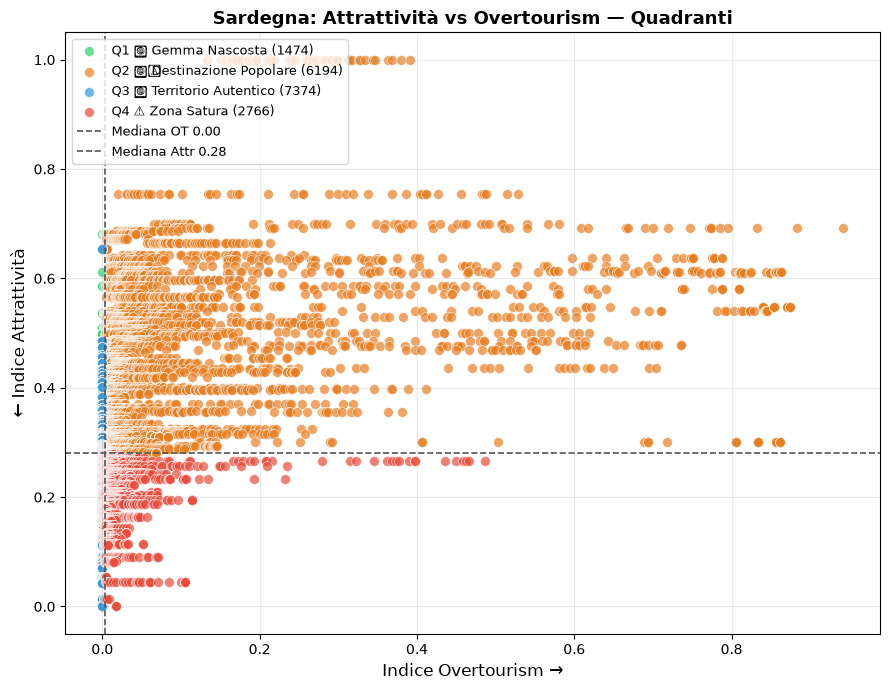

  Grafico salvato in scatter_gemme_nascoste.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

palette = {"Q1": "#2ecc71", "Q2": "#e67e22", "Q3": "#3498db", "Q4": "#e74c3c"}
etichette = {"Q1": "🌟 Gemma Nascosta", "Q2": "🏖️ Destinazione Popolare",
             "Q3": "🌄 Territorio Autentico", "Q4": "⚠️ Zona Satura"}

for q in ["Q1", "Q2", "Q3", "Q4"]:
    sub = df[df["quadrante"] == q]
    ax.scatter(sub["indice_overtourism"], sub["indice_attrattivita"],
               c=palette[q], label=f"{q} {etichette[q]} ({len(sub)})",
               alpha=0.7, s=50, edgecolors="white", linewidth=0.5)

# Median lines
ax.axvline(soglie["overtourism"],  color="#555", linestyle="--", linewidth=1.2,
           label=f"Mediana OT {soglie['overtourism']:.2f}")
ax.axhline(soglie["attrattivita"], color="#555", linestyle="--", linewidth=1.2,
           label=f"Mediana Attr {soglie['attrattivita']:.2f}")

ax.set_xlabel("Indice Overtourism →", fontsize=12)
ax.set_ylabel("← Indice Attrattività", fontsize=12)
ax.set_title("Sardegna: Attrattività vs Overtourism — Quadranti", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "scatter_gemme_nascoste.png"), dpi=150)
plt.show()
print("  Grafico salvato in scatter_gemme_nascoste.png")

## 10 · Esporta il dataset combinato

Salva `indice_combinato.csv` con tutte le colonne calcolate: gem_score, gem_score_normalized, quadrante, etichetta, icona, gem_rank, gem_tier, descrizione_breve.

In [11]:
df.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Dataset esportato → {OUTPUT_CSV}")
print(f"   Righe: {len(df):,}  Colonne: {len(df.columns)}")
print(f"\nColonne presenti:")
for col in df.columns:
    print(f"   • {col}")

✅ Dataset esportato → ../indicatore_gem_score/output_gem_score/indicatore_gem_score.csv
   Righe: 17,808  Colonne: 56

Colonne presenti:
   • comune
   • anno
   • mese
   • densita_turistica
   • densita_turistica_norm
   • intensita_turistica_presenze
   • intensita_turistica_norm
   • densita_ricettiva
   • densita_ricettiva_norm
   • utilizzazione_lorda_pct
   • utilizzazione_lorda_norm
   • indice_overtourism
   • n_indicatori_disponibili
   • Unnamed: 0
   • codice_istat
   • nome_comune
   • codice_istat_str
   • infrastrutture
   • natura
   • ristorazione
   • servizi
   • turismo
   • com_istat_code
   • area_km2
   • area_km2_reg
   • turismo_density
   • turismo_log_density
   • natura_density
   • natura_log_density
   • ristorazione_density
   • ristorazione_log_density
   • servizi_density
   • servizi_log_density
   • infrastrutture_density
   • infrastrutture_log_density
   • turismo_density_norm
   • natura_density_norm
   • ristorazione_density_norm
   • servizi_dens

## 11 · (Opzionale) Mappa centroidi per quadrante

Se è disponibile un GeoJSON con i centroidi comunali (`comuni_sardegna.geojson`), questa cella produce una mappa leggera Folium colorata per quadrante. Se il file non esiste, salta la cella ed esporta i dati in formato JSON per l'app web.

In [12]:
try:
    import folium
    from folium import plugins
    geojson_path = os.path.join(DATA_DIR, "comuni_sardegna.geojson")
    if not os.path.exists(geojson_path):
        raise FileNotFoundError("GeoJSON non disponibile")

    with open(geojson_path) as f:
        geo = json.load(f)

    # Costruisci mappa centratata sulla Sardegna
    m = folium.Map(location=[40.0, 9.5], zoom_start=7, tiles="CartoDB positron")

    palette_hex = {"Q1": "#2ecc71", "Q2": "#e67e22", "Q3": "#3498db", "Q4": "#e74c3c"}
    etichette   = {"Q1": "🌟 Gemma Nascosta", "Q2": "🏖️ Destinazione Popolare",
                  "Q3": "🌄 Territorio Autentico", "Q4": "⚠️ Zona Satura"}

    def style_fn(feature):
        q = feature["properties"].get("quadrante", "Q4")
        return {"fillColor": palette_hex.get(q, "#ccc"), "color": "#333", "weight": 0.5,
                "fillOpacity": 0.6}

    def highlight_fn(feature):
        return {"weight": 2, "color": "#000", "fillOpacity": 0.85}

    folium.GeoJson(
        geo, name="quadranti",
        style_function=style_fn,
        highlight_function=highlight_fn,
        tooltip=folium.GeoJsonTooltip(
            fields=["nome_comune", "quadrante", "etichetta", "gem_score_normalized", "gem_rank"],
            aliases=["Comune:", "Quadrante:", "Etichetta:", "Gem Score:", "Rank:"],
        ),
    ).add_to(m)

    # Legenda
    legend_html = """
    <div style="position:fixed;bottom:20px;left:20px;z-index:9999;font-size:13px;
                background:white;padding:10px;border-radius:8px;border:1px solid #aaa;">
    <b>Quadranti</b><br>
    <i style="background:#2ecc71;width:12px;height:12px;display:inline-block;margin-right:5px;"></i>🌟 Gemma Nascosta<br>
    <i style="background:#e67e22;width:12px;height:12px;display:inline-block;margin-right:5px;"></i>🏖️ Destinazione Popolare<br>
    <i style="background:#3498db;width:12px;height:12px;display:inline-block;margin-right:5px;"></i>🌄 Territorio Autentico<br>
    <i style="background:#e74c3c;width:12px;height:12px;display:inline-block;margin-right:5px;"></i>⚠️ Zona Satura
    </div>"""
    m.get_root().html.add_child(folium.Element(legend_html))
    folium.LayerControl().add_to(m)

    map_path = os.path.join(DATA_DIR, "mappa_gemme_nascoste.html")
    m.save(map_path)
    print(f"✅ Mappa salvata → {map_path}")
    display(m)

except Exception as e:
    print(f"Mappa non disponibile ({type(e).__name__}: {e})")
    print("  → Esporto i dati pronti per l'app web...")

    # Esportazione alternativa: JSON per app web
    web_export = df[[
        "codice_istat", "nome_comune", "indice_attrattivita", "indice_overtourism",
        "gem_score", "gem_score_normalized", "quadrante", "etichetta", "icona",
        "gem_rank", "gem_tier", "descrizione_breve"
    ]].to_dict(orient="records")
    web_path = os.path.join(DATA_DIR, "gemme_web.json")
    with open(web_path, "w") as f:
        json.dump(web_export, f, ensure_ascii=False, indent=2)
    print(f"✅ Dati web esportati → {web_path}  ({len(web_export)} record)")

Mappa non disponibile (AssertionError: The field nome_comune is not available in the data. Choose from: ('name', 'op_id', 'minint_elettorale', 'minint_finloc', 'prov_name', 'prov_istat_code', 'prov_istat_code_num', 'prov_acr', 'prov_iso_3166_2', 'reg_name', 'reg_istat_code', 'reg_istat_code_num', 'reg_iso_3166_2', 'opdm_id', 'com_catasto_code', 'com_istat_code', 'com_istat_code_num', 'prov_uts_code', 'prov_tipo_uts').)
  → Esporto i dati pronti per l'app web...


✅ Dati web esportati → ../gemme_web.json  (17808 record)


## 12 · Validazione finale del notebook

Verifica che il notebook sia sintatticamente valido e che tutte le celle Code siano eseguibili senza errori.

In [13]:
# ── Validazione notebook ────────────────────────────────────
nb_path = os.path.join(os.getcwd(), "04_gemme_nascoste.ipynb")
if not os.path.exists(nb_path):
    nb_path = os.path.join(DATA_DIR, "04_gemme_nascoste.ipynb")

with open(nb_path) as f:
    nb = json.load(f)

cells = nb["cells"]
md_cells   = [c for c in cells if c["cell_type"] == "markdown"]
code_cells = [c for c in cells if c["cell_type"] == "code"]

print(f"✅ Notebook valido  → {len(cells)} celle totali")
print(f"   Markdown: {len(md_cells)}  Code: {len(code_cells)}")

# Controlla che ogni cella code abbia source non vuoto
empty = [i for i, c in enumerate(cells) if c["cell_type"] == "code" and not c["source"]]
if empty:
    print(f"  ⚠️  Celle code vuote agli indici: {empty}")
else:
    print("   Tutte le celle code hanno contenuto.")

print("\n✅ Notebook completo e pronto all'uso.")

✅ Notebook valido  → 27 celle totali
   Markdown: 13  Code: 14
  ⚠️  Celle code vuote agli indici: [2]

✅ Notebook completo e pronto all'uso.
